# How to produce MF35 covariance matrices with NJOY

In [441]:
import sandy

In [442]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

In [443]:
import numpy as np
import pandas as pd
import pytest

## Produce covariance matrices (absolute units) with NJOY

For this exercise we start with JEFF-3.3 data, and then we'll move to ENDF/B-VIII.1 for cross-checking.

In [107]:
tape_j33 = sandy.get_endf6_file('jeff_33', 'xs', 922350)
tape_b81 = sandy.get_endf6_file('endfb_81', 'xs', 922350)

As for xs and nubar, the pfns covariance data in MF35 is processed with the ERRORR module with NJOY.

Here we parametrically vary the ERRORR energy grid to check how it affects the processing.

Also, we request covariance data in absolute values (although sandy always uses relative covariance matrices for sampling).

In [108]:
common_kws = dict(
    err=0.1,  # to ensure fast processing, not for production
    nubar=False,
    mubar=False,
    xs=False,
)

This file is processed with `ign=2`, equivalent to the CSEWG 238-group structure.

In [466]:
errorrj33_238_238 = tape_j33.get_errorr(
    groupr_kws = dict(ign=2),
    errorr_kws = dict(ign=2, relative=False),
    **common_kws
)['errorr35']

    If you want to process 0K cross sections use `temperature=0.1`.
    


This file is processed with `ign=19`, equivalent to the ECCO 33-group structure.

In [447]:
errorrj33_33_33 = tape_j33.get_errorr(
    groupr_kws = dict(ign=19),
    errorr_kws = dict(ign=19, relative=False),
    **common_kws
)['errorr35']

    If you want to process 0K cross sections use `temperature=0.1`.
    


Mixing different `ign` numbers or `ek` structure will either not work or produce normalization problems. Then, i wouldn't do it. 

### Check PFNS

PFNS are collected with the `Errorr` method `get_xs`.
For some resaon NJOY reports bin-integrated values (they sum to 1).

Covariance data and standard deviations are also extracted with `get_cov`.

In [468]:
xsj33_238_238 = errorrj33_238_238.get_xs().data.squeeze().pipe(lambda x: pd.Series(x.values, index=x.index.right))
integralj33_238_238 = xsj33_238_238.sum()
xsj33_238_238 /= xsj33_238_238.index.diff()
covj33_238_238 = errorrj33_238_238.get_cov().data
stdj33_238_238 = errorrj33_238_238.get_cov().get_std().pipe(lambda x: pd.Series(x.values, index=x.index.get_level_values("E").right))

xsj33_33_33 = errorrj33_33_33.get_xs().data.squeeze().pipe(lambda x: pd.Series(x.values, index=x.index.right))
integralj33_33_33 = xsj33_33_33.sum()
xsj33_33_33 /= xsj33_33_33.index.diff()
covj33_33_33 = errorrj33_33_33.get_cov().data
stdj33_33_33 = errorrj33_33_33.get_cov().get_std().pipe(lambda x: pd.Series(x.values, index=x.index.get_level_values("E").right))

A visual comparison shows a good match for the two cases.

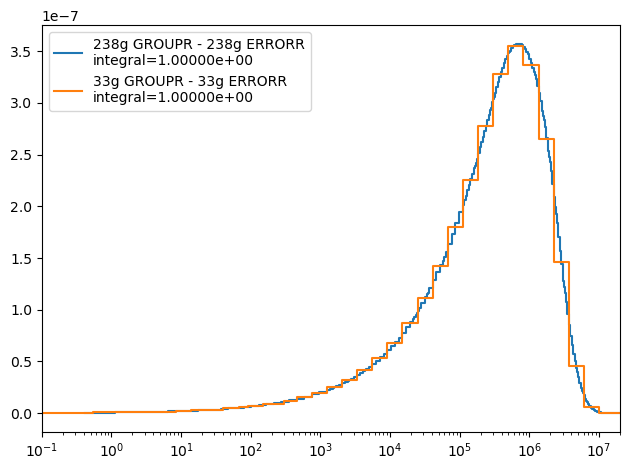

In [488]:
fig, ax = plt.subplots()

xsj33_238_238.plot(
    ds='steps-pre',
    ls='-',
    label=f'238g GROUPR - 238g ERRORR\nintegral={integralj33_238_238:.5e}',
)

xsj33_33_33.plot(
    ds='steps-pre',
    ls='-',
    label=f'33g GROUPR - 33g ERRORR\nintegral={integralj33_33_33:.5e}',
)

ax.set(xscale='log', xlim=(1e-1, 2e7))
ax.legend()

fig.tight_layout()

### Check standard deviation

Also the standard deviations look ok.

Surprinsingly we see a dip in the relative standard deviation at 2 MeV.

Also, the uncertainty over 238 groups (more groups above 1 MeV) has large values up to 60% at 10 MeV.

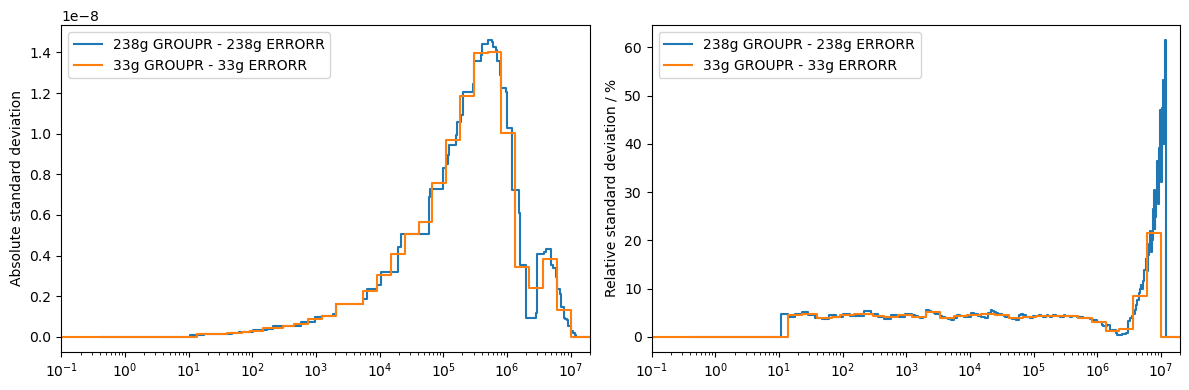

In [489]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
stdj33_238_238.plot(ax=ax, ds='steps-pre', label=f'238g GROUPR - 238g ERRORR')
stdj33_33_33.plot(ax=ax, ds='steps-pre', label=f'33g GROUPR - 33g ERRORR', ls='-')
ax.legend()
ax.set(xscale='log', xlim=(1e-1, 2e7), ylabel="Absolute standard deviation")

ax = axs[1]
(stdj33_238_238 / xsj33_238_238 * 100).plot(ax=ax, ds='steps-pre', label=f'238g GROUPR - 238g ERRORR')
(stdj33_33_33 / xsj33_33_33 * 100).plot(ax=ax, ds='steps-pre', label=f'33g GROUPR - 33g ERRORR', ls='-')
ax.legend()
ax.set(xscale='log', xlim=(1e-1, 2e7), ylabel="Relative standard deviation / %")

fig.tight_layout()

### Check covariance data

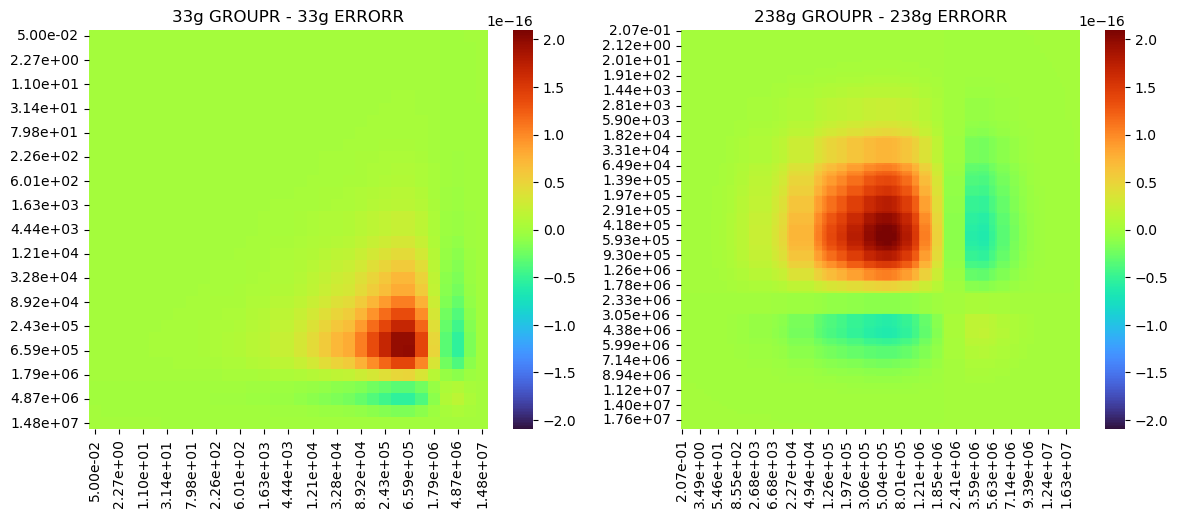

In [472]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

vmin = -2.1e-16
vmax = 2.1e-16
cmap = "turbo"

ax = axs[0]
ax.set_aspect("equal")
heatmap = covj33_33_33.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
# Get the current tick positions
xticks = ax.get_xticks()
yticks = ax.get_yticks()
# Replace tick labels with formatted strings
ax.set_xticklabels([f"{heatmap.columns[int(i)]:.2e}" for i in xticks if i < len(heatmap.columns)])
ax.set_yticklabels([f"{heatmap.index[int(i)]:.2e}" for i in yticks if i < len(heatmap.index)])
ax.set(title=f'33g GROUPR - 33g ERRORR')

ax = axs[1]
ax.set_aspect("equal")
heatmap = covj33_238_238.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
# Get the current tick positions
xticks = ax.get_xticks()
yticks = ax.get_yticks()
# Replace tick labels with formatted strings
ax.set_xticklabels([f"{heatmap.columns[int(i)]:.2e}" for i in xticks if i < len(heatmap.columns)])
ax.set_yticklabels([f"{heatmap.index[int(i)]:.2e}" for i in yticks if i < len(heatmap.index)])
ax.set(title=f'238g GROUPR - 238g ERRORR')


fig.tight_layout()

The absolute covariance matrices seem also ok.

We continue the checks by converting into relative units. Here the higher-resolution in the high-energy groups is quite evident, which explains the differences in standard devaitions previously reported.

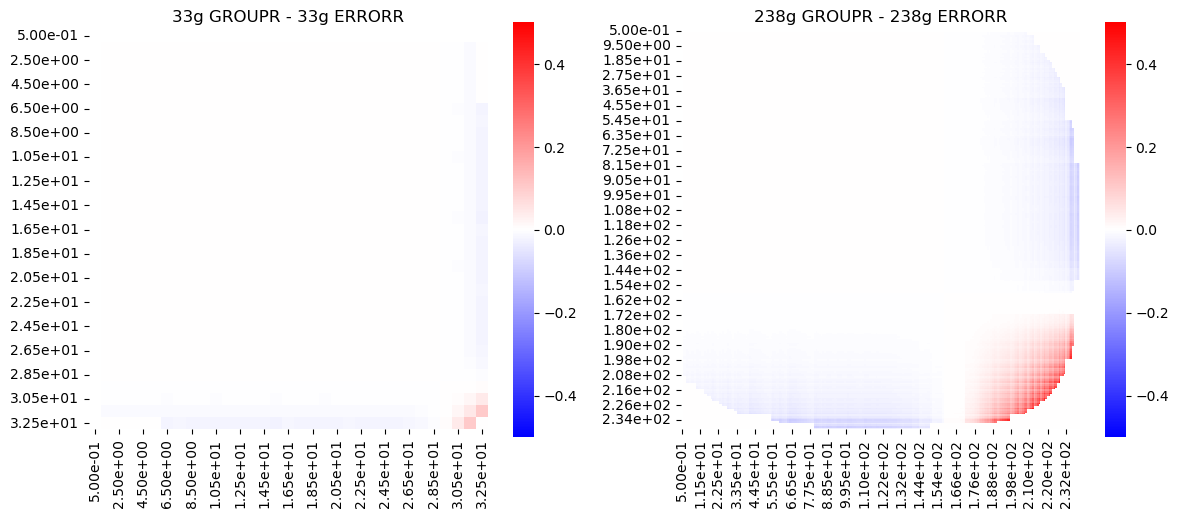

In [477]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

vmin = -0.5
vmax = 0.5
cmap = "bwr"

ax = axs[0]
ax.set_aspect("equal")
heatmap = covj33_33_33.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
heatmap /= (xsj33_33_33.to_frame() @ xsj33_33_33.to_frame().T).values
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.set(title=f'33g GROUPR - 33g ERRORR')

ax = axs[1]
ax.set_aspect("equal")
heatmap = covj33_238_238.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
heatmap /= (xsj33_238_238.to_frame() @ xsj33_238_238.to_frame().T).values
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.set(title=f'238g GROUPR - 238g ERRORR')

fig.tight_layout()

A check of the matrix structure shows a non-symmetric pattern when processing over 238g.
Some zeroes appear on one side (white), but not on the other.

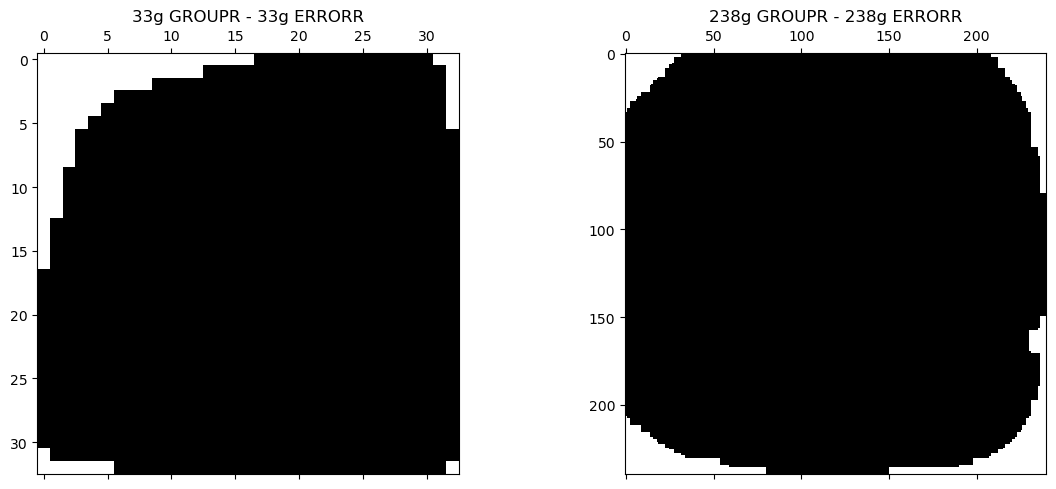

In [478]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

ax = axs[0]
ax.set_aspect("equal")
heatmap = covj33_33_33.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
ax.spy(heatmap)
ax.set(title=f'33g GROUPR - 33g ERRORR')

ax = axs[1]
ax.set_aspect("equal")
heatmap = covj33_238_238.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
ax.spy(heatmap)
ax.set(title=f'238g GROUPR - 238g ERRORR')

fig.tight_layout()

A plot of the elementwise difference between the covariance matrix (converted to relative units) and its transpose shows significant asymmetries. These deviations (although small in absolute units) will affect sampling quality; they are also above the tolerance of sandy’s covariance checks.

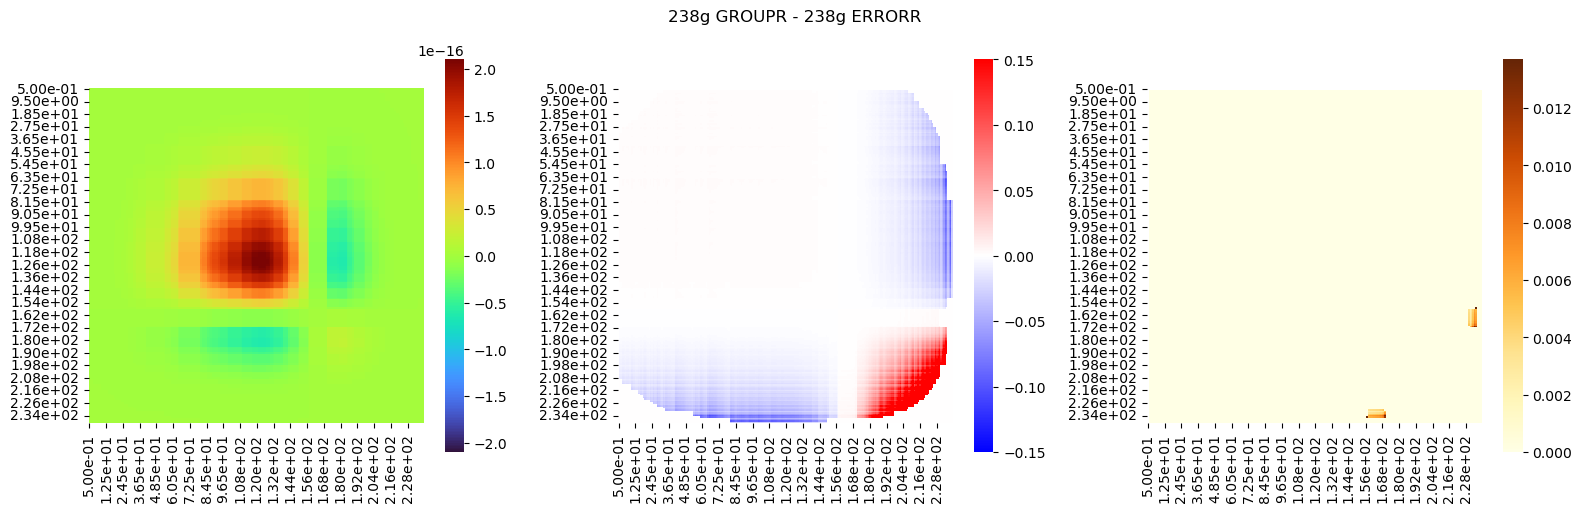

In [508]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

ax = axs[0]
vmin = -2.1e-16
vmax = 2.1e-16
cmap = "turbo"
ax.set_aspect("equal")
heatmap = covj33_238_238.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))

ax = axs[1]
vmin = -0.15
vmax = 0.15
cmap = "bwr"
ax.set_aspect("equal")
heatmap = covj33_238_238.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
heatmap /= (xsj33_238_238.to_frame() @ xsj33_238_238.to_frame().T).values
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))

ax = axs[2]
ax.set_aspect("equal")
heatmap = covj33_238_238.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
heatmap /= (xsj33_238_238.to_frame() @ xsj33_238_238.to_frame().T).values
#heatmap = covj33_238_238.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
sns.heatmap((heatmap - heatmap.T).abs(), ax=ax, cmap="YlOrBr")
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))

fig.suptitle(f'238g GROUPR - 238g ERRORR')
fig.tight_layout()

## Asking NJOY for relative covariance data

Asking NJOY for a covariance matrix in absolute units, and then converting it into relative units, produced asymmetries.

Let's now change the NJOY input arguments and ask for covariance data in relative units.

In [481]:
errorrj33_238_238_rel = tape_j33.get_errorr(
    groupr_kws = dict(ign=2),
    errorr_kws = dict(ign=2, relative=True),
    **common_kws
)['errorr35']

    If you want to process 0K cross sections use `temperature=0.1`.
    


In [482]:
errorrj33_33_33_rel = tape_j33.get_errorr(
    groupr_kws = dict(ign=19),
    errorr_kws = dict(ign=19, relative=True),
    **common_kws
)['errorr35']

    If you want to process 0K cross sections use `temperature=0.1`.
    


Using user-defined structures can be done by replacing the `ign` entry with keyword argument `ek=sandy.energy_grid.SCALE238` (for instance) both in `groupr_kws` and `errorr_kws`.
Still, when i tried it using `relative=True` i got a non-symmetric matrix from NJOY. 

### Check PFNS

Again, the multigroup PFNS seems ok.

In [510]:
# 238 g GROUPR + 238 g ERRORR
xsj33_238_238_rel = errorrj33_238_238_rel.get_xs().data.squeeze().pipe(lambda x: pd.Series(x.values, index=x.index.right))
integralj33_238_238_rel = xsj33_238_238_rel.sum()
xsj33_238_238_rel /= xsj33_238_238_rel.index.diff()
covj33_238_238_rel = errorrj33_238_238_rel.get_cov().data
stdj33_238_238_rel = errorrj33_238_238_rel.get_cov().get_std().pipe(lambda x: pd.Series(x.values, index=x.index.get_level_values("E").right))

# 33 g GROUPR + 33 g ERRORR
xsj33_33_33_rel = errorrj33_33_33_rel.get_xs().data.squeeze().pipe(lambda x: pd.Series(x.values, index=x.index.right))
integralj33_33_33_rel = xsj33_33_33_rel.sum()
xsj33_33_33_rel /= xsj33_33_33_rel.index.diff()
covj33_33_33_rel = errorrj33_33_33_rel.get_cov().data
stdj33_33_33_rel = errorrj33_33_33_rel.get_cov().get_std().pipe(lambda x: pd.Series(x.values, index=x.index.get_level_values("E").right))

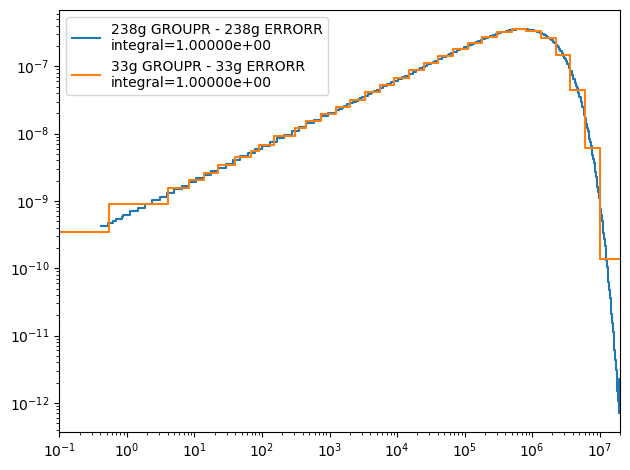

In [512]:
fig, ax = plt.subplots()

xsj33_238_238_rel.plot(
    ds='steps-pre',
    ls='-',
    label=f'238g GROUPR - 238g ERRORR\nintegral={integralj33_238_238_rel:.5e}',
)

xsj33_33_33_rel.plot(
    ds='steps-pre',
    ls='-',
    label=f'33g GROUPR - 33g ERRORR\nintegral={integralj33_33_33_rel:.5e}',
)

ax.set(xscale='log', yscale='log', xlim=(1e-1, 2e7))
ax.legend()

fig.tight_layout()

### Check standard deviation

Standard deviations are fairly different when using the command `relative=True` or `relative=False`.
These differences can be better seen whne plotting relative standard devistions.
Below 10 eV and above 20 MeV, where the PFNS goes below 10$^{-9}$, the covariance processed by NJOY in absolute units sets the uncertainty to zero.

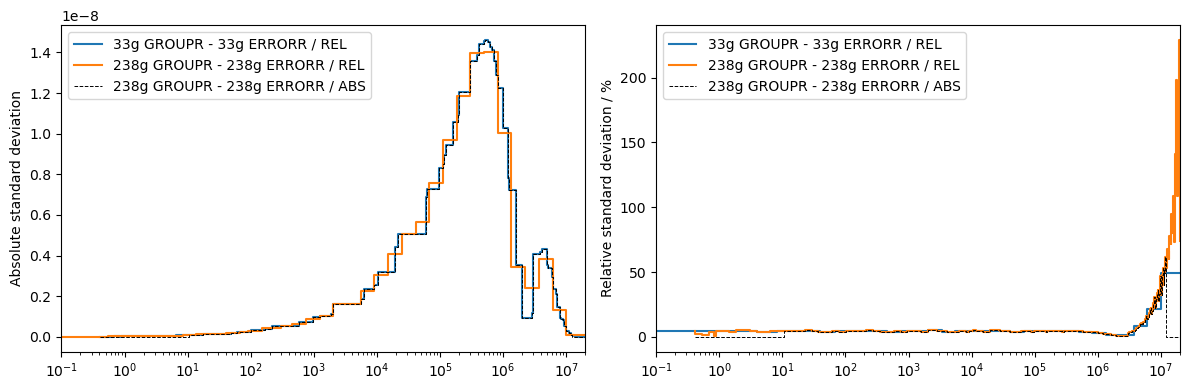

In [494]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
(stdj33_238_238_rel * xsj33_238_238_rel).plot(ax=ax, ds='steps-pre', label=f'33g GROUPR - 33g ERRORR / REL')
(stdj33_33_33_rel * xsj33_33_33_rel).plot(ax=ax, ds='steps-pre', label=f'238g GROUPR - 238g ERRORR / REL')
stdj33_238_238.plot(ax=ax, ds='steps-pre', label=f'238g GROUPR - 238g ERRORR / ABS', c='k', ls='--', lw=.7)
ax.legend()
ax.set(xscale='log', xlim=(1e-1, 2e7), ylabel="Absolute standard deviation")

ax = axs[1]
(stdj33_33_33_rel * 100).plot(ax=ax, ds='steps-pre', label=f'33g GROUPR - 33g ERRORR / REL')
(stdj33_238_238_rel * 100).plot(ax=ax, ds='steps-pre', label=f'238g GROUPR - 238g ERRORR / REL')
(stdj33_238_238 / xsj33_238_238 * 100).plot(ax=ax, ds='steps-pre', label=f'238g GROUPR - 238g ERRORR / ABS', c='k', ls='--', lw=.7)
ax.legend(loc=2)
ax.set(xscale='log', xlim=(1e-1, 2e7), ylabel="Relative standard deviation / %")

fig.tight_layout()

### Check covariance data

This difference, especially at high energy, is fairly evident when plotting the relative covariance matrix.

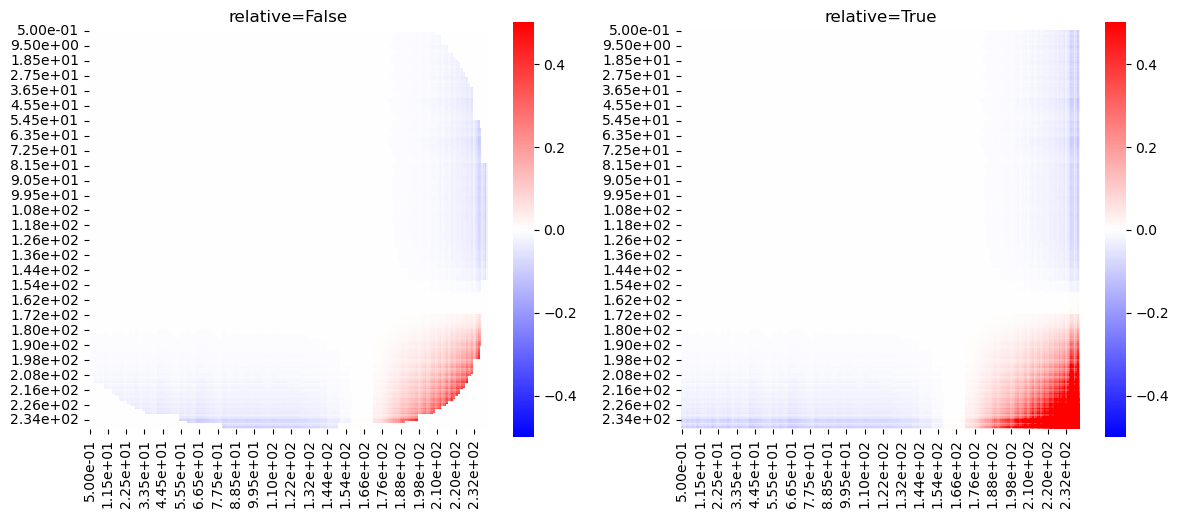

In [519]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

ax = axs[0]
vmin = -0.5
vmax = 0.5
cmap = "bwr"
ax.set_aspect("equal")
heatmap = covj33_238_238.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
heatmap /= (xsj33_238_238_rel.to_frame() @ xsj33_238_238_rel.to_frame().T).values
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.set(title=f'relative=False')

ax = axs[1]
vmin = -0.5
vmax = 0.5
cmap = "bwr"
ax.set_aspect("equal")
heatmap = covj33_238_238_rel.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.set(title=f'relative=True')

fig.tight_layout()

The distance between the covariance matrix and its transpose is at most 10$^{-8}$, i.e. negligible for sampling and below Sandy’s covariance-check thresholds.

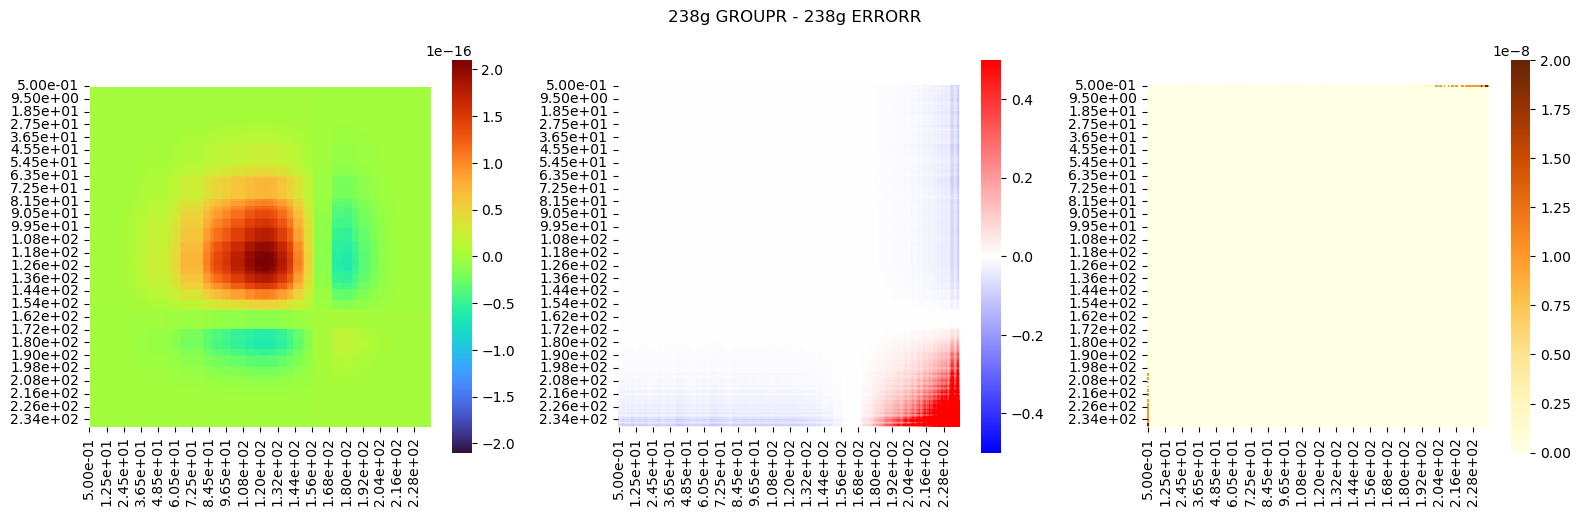

In [520]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

ax = axs[0]
vmin = -2.1e-16
vmax = 2.1e-16
cmap = "turbo"
ax.set_aspect("equal")
heatmap = covj33_238_238_rel.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
heatmap *= (xsj33_238_238_rel.to_frame() @ xsj33_238_238_rel.to_frame().T).values
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))

ax = axs[1]
vmin = -0.5
vmax = 0.5
cmap = "bwr"
ax.set_aspect("equal")
heatmap = covj33_238_238_rel.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
sns.heatmap(heatmap, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))

ax = axs[2]
ax.set_aspect("equal")
heatmap = covj33_238_238_rel.pipe(lambda x: pd.DataFrame(x.values, index=x.index.get_level_values("E").mid, columns=x.columns.get_level_values("E").mid))
sns.heatmap((heatmap - heatmap.T).abs(), ax=ax, cmap="YlOrBr")
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:.2e}'))

fig.suptitle(f'238g GROUPR - 238g ERRORR')
fig.tight_layout()

## Conclusion

Covariance matrices for PFNS stored in MF35 should be processed with NJOY in relative units, and using a fine group structure above 1 MeV.